In [8]:
# Darstellung anpassen

from IPython.display import display, HTML

display(HTML(data="""
<style>
    div#notebook-container    { width: 95%; }
    div#menubar-container     { width: 65%; }
    div#maintoolbar-container { width: 99%; }
</style>
"""))



In [9]:
# Lade benötigte Programmpakete

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import sklearn as sk
import joblib


In [10]:
from sklearn.datasets import fetch_openml # Lade den MNIST_784-Datensatz
mnist=fetch_openml('mnist_784',as_frame=False,parser='auto')

In [11]:
X=mnist['data'] # Features, 
y=mnist['target'] # Labels
print(f"Shape of X: {X.shape}")
# Teile in Trainings und Test-Daten. Verwende die ersten 60000 Bilder zum trainieren und die letzten 10000 zum Testen
X_train=X[:60000,:]
y_train=y[:60000]
X_test=X[60000:,:]
y_test=y[60000:]



Shape of X: (70000, 784)


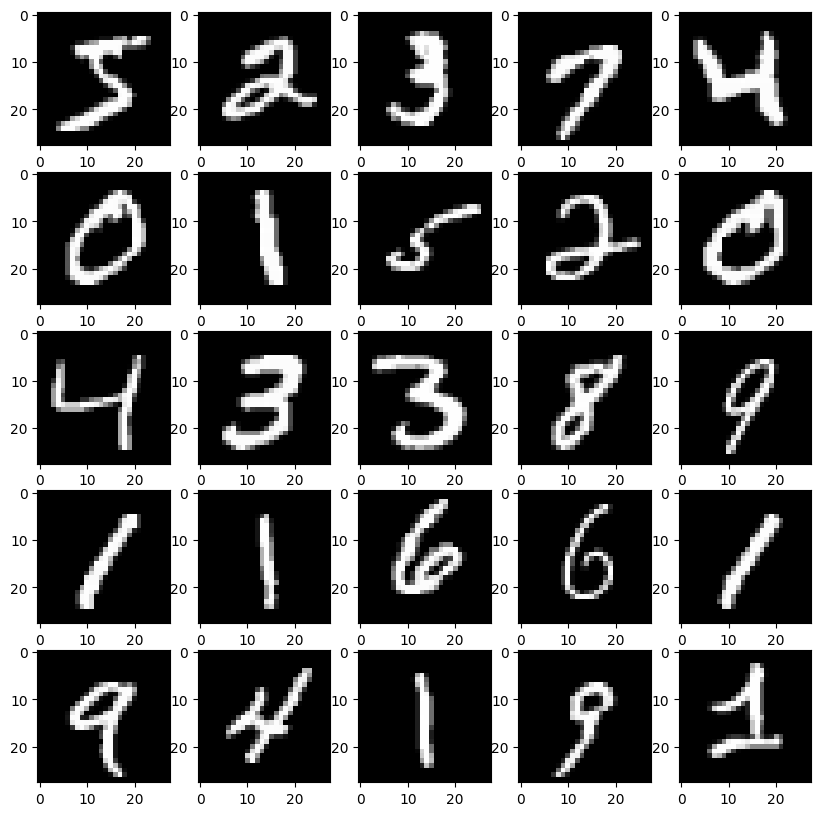

In [12]:
# Plotte Beispielbilder der Ziffern
fig,ax=plt.subplots(5,5,figsize=(10,10))
for i in range(25):
    j=i%5
    k=i//5

    test_image=X[i].reshape(28,28)
    ax[j,k].imshow(test_image,cmap='gray',vmin=0, vmax=255)

##### Entwickeln Sie einen Classifier der die Ziffer '5' erkennt. Verwenden Sie zur Entwicklung den Trainingsdatensatz X_train, y_train und verwenden Sie die in der LV besprochenen Methoden um ein optimales Modell mit optimalen Hyperparametern zu entwickeln. Erst wenn Sie fertig sind, und überzeugt das bestmögliche Modell gefunden zu haben, Werten Sie ihre Daten am Test-Datensatz aus. 

In [13]:
# Preprocsessing
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
print(scaler.fit(X_train))
print(scaler.data_max_)
print(scaler.transform(X_train))
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 
y_train_binary = (y_train == "5") # why is this a string???????
y_test_binary = (y_test == "5")


MinMaxScaler()
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. 116. 254.
 216.   9.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.  16.  47. 157. 254. 255. 254. 255. 255. 255. 255.
 255. 255. 255. 255. 255. 255. 244. 255. 184. 197.   0.   0.   0.   0.
   0.   0.  64.  29. 134.  62. 234. 255. 255. 255. 255. 255. 255. 255.
 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 165.   0.   0.
   0.   0. 141. 101.  96. 255. 255. 255. 255. 255. 255. 255. 255. 255.
 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 192. 121.   0.
   0.  38. 144. 101. 254. 255. 255. 255. 255. 255. 255. 255. 255. 255.
 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 254. 221.  63.
   0.   0.  95. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255.
 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255.  93.
   0.   7. 210. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255.
 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 2

In [14]:
# basic training runs in single core => can take a while; C=10 ~ 2 minutes, used for prep
from sklearn.svm import SVC
basic_svc=SVC(C=10) # probability=True
basic_svc.fit(X_train_scaled, y_train_binary)
joblib.dump(basic_svc, "models/svc_model_binary_basic.joblib")

['models/svc_model_binary_basic.joblib']

Finding optimal Hyperparameters by using GridSearchCV, even when using a low amout of splits, parameters training takes a lot of time, even with parallization...      
1fit with C=10 ~ 1:40


In [ ]:
# binary => 1.5 Stunden Rechenzeiot Octa Core
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.svm import SVC
svc=SVC(kernel='rbf') 
cs = list(np.logspace(0, 2, 4)) + [10] #default 1 
gammas = list(np.logspace(-6, -4, 2)) + ['scale'] # scale = 1/n_samples default value
params = {
    'C': cs,
    'gamma': gammas,
}

gs_binary = GridSearchCV(svc, params, cv=KFold(n_splits=4), scoring = "balanced_accuracy", verbose=3, n_jobs=-1)#n_jobs=-1 => alle Kerne nutzen
gs_binary.fit(X_train_scaled, y_train_binary)

joblib.dump(gs_binary, "models/svc_model_binary_good.joblib")

Fitting 4 folds for each of 15 candidates, totalling 60 fits


['models/svc_model_binary_good.joblib']

Aufgrund der des großen Trainingsdatensatzes kommt es bie hohen C/gamma zu extrem hohen Rechenzeiten.

In [31]:
# Optimale Parameter
print(f"Best score: {gs_binary.best_params_}")

Best score: {'C': 10, 'gamma': 'scale'}


In [ ]:
# non biary, all digits
from sklearn.model_selection import GridSearchCV, KFold

svc=SVC(kernel='rbf')# probability=True

cs = np.logspace(-1, 3, 4) 
# gammas = [1/600000, 1/60000, 1/6000] # 1/n_samples default value
params = {
    'C': cs,
    # 'gamma': gammas,
}

gs = GridSearchCV(svc, params, cv=KFold(n_splits=4), scoring = "balanced_accuracy", verbose=3, n_jobs=-1)#n_jobs=-1 => alle Kerne nutzen, einen thread für
gs.fit(X_train_scaled, y_train)

joblib.dump(gs, "models/svc_model_good.joblib")

Fitting 4 folds for each of 4 candidates, totalling 16 fits


['models/svc_model_good.joblib']

In [38]:
svc = joblib.load("models/svc_model_binary_good.joblib")
# Optimale Parameter
print(f"Best score: {svc.best_params_}")

Best score: {'C': 10, 'gamma': 'scale'}


Um die Rechenzeit für die Auswertung des Modells zu reduzieren werden Test und Trainingsdatensatz auf alle Kerne der CPU aufgeteilt um eine parallele berechnung zu ermöglichen.

In [39]:
import os
number_of_cpus = os.cpu_count()

In [ ]:
# 2 seconds
from joblib import Parallel, delayed

def batch_predict(model, X_batch):
    return model.predict(X_batch)

# Split data into 4 chunks
X_chunks = np.array_split(X_test_scaled, number_of_cpus)

# Predict in parallel
predictions = Parallel(n_jobs=number_of_cpus)(delayed(batch_predict)(svc, chunk) for chunk in X_chunks)

# Concatenate results
y_pred = np.concatenate(predictions)
accuracy = (y_pred == y_test_binary).mean()
print("Accuracy on test set:", accuracy)

Accuracy on test set: 0.9974


In [41]:
# 10 seconds 
X_chunks = np.array_split(X_train_scaled, number_of_cpus)

# Predict in parallel
predictions = Parallel(n_jobs=number_of_cpus-2)(delayed(batch_predict)(svc, chunk) for chunk in X_chunks)

# Concatenate results
y_pred_train = np.concatenate(predictions)
accuracy = (y_pred_train == y_train_binary).mean()
print("Accuracy on train set:", accuracy)

Accuracy on train set: 0.9999833333333333


In [37]:
y_pred

array(['7', '2', '1', ..., '4', '5', '6'], shape=(10000,), dtype=object)

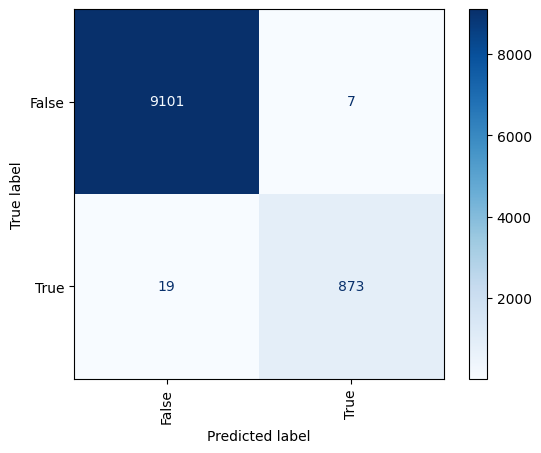

In [43]:
#gpt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
confusion_matrix = confusion_matrix(y_test_binary, y_pred)
cmd = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=svc.classes_)
cmd.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')


In [45]:
cr = classification_report(y_test_binary, y_pred)
print(cr)

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      9108
        True       0.99      0.98      0.99       892

    accuracy                           1.00     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       1.00      1.00      1.00     10000



Fasle positives, False Negatives:

False Positives: [ 449 1014 2185 2939 3567 3943 4536]
False Negatives: [ 720  951 1082 1393 1641 1737 2035 2224 2369 2597 3117 3558 4355 5769
 5997 6598 9729 9749 9770]
0 449
1 1014
2 2185
3 2939
4 3567


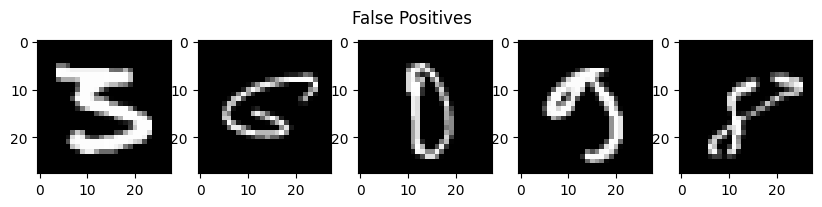

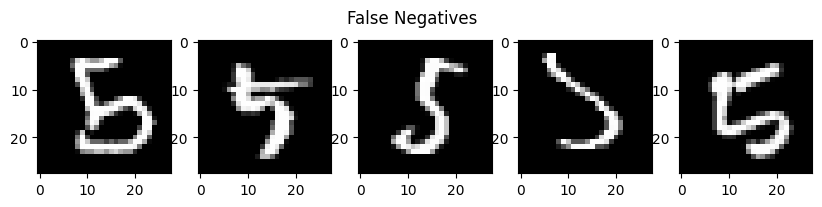

In [24]:
false_positives = np.where((y_test_binary == 0) & (y_pred == 1))[0]
false_negatives = np.where((y_test_binary == 1) & (y_pred == 0))[0]
print("False Positives:", false_positives)
print("False Negatives:", false_negatives)

false_positives = false_positives[:5]  # Limit to 5 for display
false_negatives = false_negatives[:5]  # Limit to 5 for display

fig,ax=plt.subplots(1,5,figsize=(10,2))
fig.suptitle("False Positives")
for id, i in enumerate(false_positives):
    print(id, i)
    test_image=X_test[i].reshape(28,28)
    ax[id].imshow(test_image,cmap='gray',vmin=0, vmax=255)

fig,ax=plt.subplots(1,5,figsize=(10,2))
fig.suptitle("False Negatives")
for id, i in enumerate(false_negatives):
    test_image=X_test[i].reshape(28,28)
    ax[id].imshow(test_image,cmap='gray',vmin=0, vmax=255)

Einige der Fehler wären auch für einen Menschen plausibel. z.B.: 1. False Positive 

Alle Ziffern

In [ ]:
svc = joblib.load("models/svc_model_good.joblib")
# Optimale Parameter
print(f"Best score: {svc.best_params_}")

Best score: {'C': np.float64(46.41588833612777)}


In [ ]:
from joblib import Parallel, delayed

def batch_predict(model, X_batch):
    return model.predict(X_batch)

X_chunks = np.array_split(X_test_scaled, number_of_cpus)

# Predict in parallel
predictions = Parallel(n_jobs=number_of_cpus)(delayed(batch_predict)(svc, chunk) for chunk in X_chunks)

# Concatenate results
y_pred = np.concatenate(predictions)
accuracy = (y_pred == y_test).mean()
print("Accuracy on test set:", accuracy)

Accuracy on test set: 0.9833


In [ ]:
X_chunks = np.array_split(X_train_scaled, number_of_cpus-2)

# Predict in parallel
predictions = Parallel(n_jobs=number_of_cpus-2)(delayed(batch_predict)(svc, chunk) for chunk in X_chunks)

# Concatenate results
y_pred_train = np.concatenate(predictions)
accuracy = (y_pred_train == y_train).mean()
print("Accuracy on train set:", accuracy)

Accuracy on train set: 1.0


In [ ]:
y_pred

array(['7', '2', '1', ..., '4', '5', '6'], shape=(10000,), dtype=object)

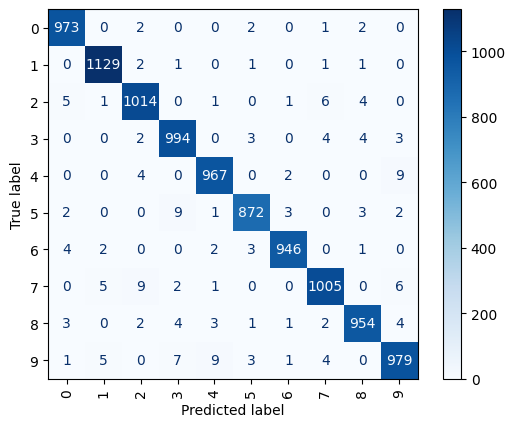

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svc.classes_)
cmd.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.show()

In [ ]:
cr = classification_report(y_test, y_pred)
print(cr)